# contact-CLASP · clasp_l4 — fusing attention with a gradient/IG map

If attention weakens in the low-Neff/L regime, can a second sequence-only signal help? We build a per-position masked-LM **gradient contact map** (the fast cousin of a full Integrated-Gradients map — the IG machinery is in [`common/ig_l1`](../common/ig_l1_simple.ipynb)) and **fuse** it with attention by rank-averaging.

In [1]:
import os, sys
ROOT = os.path.abspath("")
while ROOT != os.path.dirname(ROOT) and not os.path.isdir(os.path.join(ROOT, "common")):
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)                          # for `import common`
sys.path.insert(0, os.path.join(ROOT, "clasp"))   # for `import clasp_common`
DATA = os.path.join(ROOT, "data")
print("repo root:", ROOT)

repo root: C:\Users\soura\code\2026\xai-starter


In [2]:
from clasp_common import (load_demo_chain, esm_attention_contacts,
                          gradient_contact_map, fuse, precision_at_l)
seq, coords, true = load_demo_chain(cache_dir=DATA)
attn = esm_attention_contacts(seq)
grad = gradient_contact_map(seq)
fused = fuse(attn, grad, method='rank')
for name, m in [('attention', attn), ('gradient', grad), ('fusion', fused)]:
    print(f'{name:10s} precision@L = {precision_at_l(m, true):.3f}')

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

attention  precision@L = 0.069
gradient   precision@L = 0.155
fusion     precision@L = 0.121


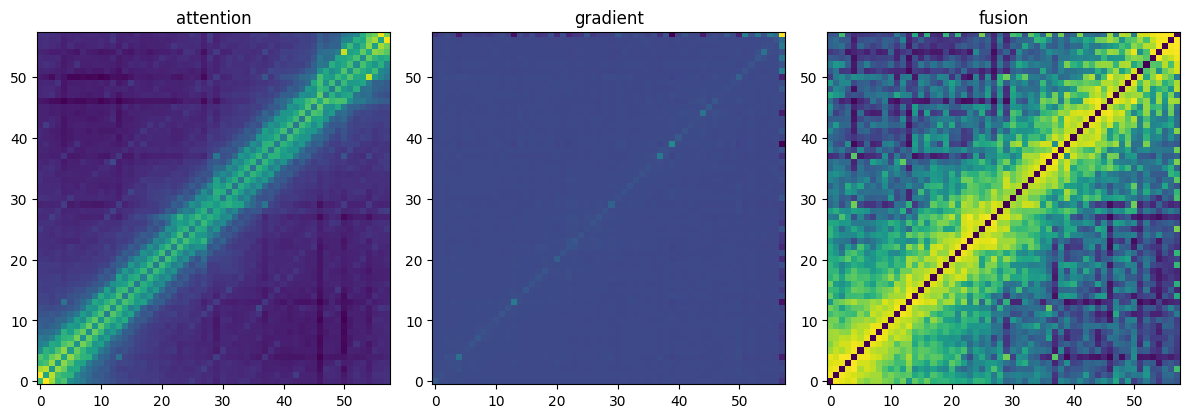

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (t, m) in zip(ax, [('attention', attn), ('gradient', grad), ('fusion', fused)]):
    a.imshow(m, cmap='viridis', origin='lower'); a.set_title(t)
plt.tight_layout(); plt.show()

### Things to experiment with
- Swap the gradient map for a true Captum **Integrated Gradients** map (`common/ig_l1`).
- Try `fuse(..., method='zscore')`; measure fusion gain specifically in the low-Neff/L bin.